# Four-target SFP: build near-optimal multi-route training data

这一 notebook 完成当前阶段的数据准备：在**原有 10,000 个训练布局**上枚举 24 种访问顺序，
保留长度不超过精确最短长度 **105%** 的所有路线。
任务仍然是从固定起点出发，访问四个目标后结束，**不返程**。

- 只读取 `datasets/v1/train.npz`，不读取验证集或测试集，不训练模型。
- 不修改 v1；新版本单独保存到 `datasets/v2_nearopt_05pct/`。
- 原来的 `starts / targets / conditions / routes / knot_tau / lengths` 等数组原样保留；
  新候选路线使用 `mode_...` 字段保存，避免误当成新的布局。
- 目标编号保持与 v1 一致，供模型沿用原来的坐标排序预处理。专家访问顺序不作为模型输入。
- 训练采样器先均匀选布局，再在该布局内均匀选路线；保留原 SFP 噪声和稳定化目标构造。
- “路线数”指不同访问排列数；不同排列的空间轨迹可能很接近，不能把计数直接等同于几何模式多样性。

将本 notebook 放在 `streaming-flow-policy` 仓库内，使用原 Python 环境，从上到下运行。
本步骤只需要 NumPy、pandas 和 matplotlib，不需要 GPU 或模型权重。
运行完成后查看路线数量统计和示例图，再接入下一阶段的单路线／多路线对照训练。


In [1]:
from pathlib import Path
import hashlib
import itertools
import json
import os
import shutil
import subprocess
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT_OVERRIDE = None  # Example: Path('/home/matcho/projects/streaming-flow-policy')
RELATIVE_SLACK = 0.05        # 5%, NOT the target-visit tolerance
EXPECTED_NUM_LAYOUTS = 10_000
NUM_EXAMPLE_LAYOUTS = 6
MAX_ROUTES_PER_PLOT = 6     # Only a display limit; ALL eligible routes are saved and sampled
SAMPLE_CONFIG = {'sigma_0': 0.05, 'stabilizing_gain': 2.5}
BUILDER_VERSION = 'four_target_multiroute_v1'
BOUNDARY_ATOL = 1e-12      # Floating-point tolerance in coordinate-length units

def find_project_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        return Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]
    try:
        proc = subprocess.run(['git', '-C', str(here), 'rev-parse', '--show-toplevel'],
                              check=True, capture_output=True, text=True)
        candidates.insert(0, Path(proc.stdout.strip()))
    except (subprocess.CalledProcessError, FileNotFoundError):
        pass
    for root in candidates:
        if (root / 'experiments/four_boxes_experiments/four_targets/datasets/v1/train.npz').is_file():
            return root
    raise FileNotFoundError('Run inside the repository or set PROJECT_ROOT_OVERRIDE.')

if not np.isfinite(RELATIVE_SLACK) or not 0 <= RELATIVE_SLACK <= 1:
    raise ValueError('RELATIVE_SLACK must be a finite fraction between 0 and 1.')
PROJECT_ROOT = find_project_root()
TASK_ROOT = PROJECT_ROOT / 'experiments/four_boxes_experiments/four_targets'
SOURCE_DIR = TASK_ROOT / 'datasets/v1'
SOURCE_PATH = SOURCE_DIR / 'train.npz'
percent_tag = f'{100 * RELATIVE_SLACK:05.2f}'.rstrip('0').rstrip('.').replace('.', 'p')
OUTPUT_DIR = TASK_ROOT / 'datasets' / f'v2_nearopt_{percent_tag}pct'
print('Source:', SOURCE_PATH)
print('New dataset:', OUTPUT_DIR)
print(f'Rule: route length <= {1 + RELATIVE_SLACK:.4f} × exact minimum length')


Source: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/datasets/v1/train.npz
New dataset: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/datasets/v2_nearopt_05pct
Rule: route length <= 1.0500 × exact minimum length


## 1. Read and check the original training split
保留原布局索引。检查源专家路线确实经过全部目标，且原时间结点与弧长参数化一致。


In [2]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

SOURCE_SHA256 = sha256_file(SOURCE_PATH)
with np.load(SOURCE_PATH, allow_pickle=False) as archive:
    source = {key: archive[key].copy() for key in archive.files}

required_keys = {'starts', 'targets', 'conditions', 'routes', 'knot_tau', 'lengths'}
missing = required_keys - source.keys()
if missing:
    raise ValueError(f'Missing source fields: {sorted(missing)}')
N_LAYOUTS = len(source['targets'])
if EXPECTED_NUM_LAYOUTS is not None and N_LAYOUTS != EXPECTED_NUM_LAYOUTS:
    raise ValueError(f'Expected {EXPECTED_NUM_LAYOUTS} layouts, found {N_LAYOUTS}.')
if N_LAYOUTS == 0:
    raise ValueError('Source dataset is empty.')
for key, shape in {'starts': (N_LAYOUTS, 2), 'targets': (N_LAYOUTS, 4, 2),
                   'conditions': (N_LAYOUTS, 10), 'routes': (N_LAYOUTS, 5, 2),
                   'knot_tau': (N_LAYOUTS, 5), 'lengths': (N_LAYOUTS,)}.items():
    if source[key].shape != shape or not np.isfinite(source[key]).all():
        raise ValueError(f'Invalid source array: {key}')

starts64 = source['starts'].astype(np.float64)
targets64 = source['targets'].astype(np.float64)
np.testing.assert_allclose(starts64, np.broadcast_to(starts64[0], starts64.shape), rtol=0, atol=1e-7)
np.testing.assert_allclose(source['conditions'], np.concatenate(
    [source['starts'], source['targets'].reshape(N_LAYOUTS, 8)], axis=1), rtol=0, atol=1e-7)
np.testing.assert_allclose(source['routes'][:, 0], source['starts'], rtol=0, atol=1e-7)

# Recover the original route's target order without assuming a source key name.
point_errors = np.linalg.norm(
    source['routes'][:, 1:, None, :].astype(np.float64) - targets64[:, None, :, :], axis=-1)
baseline_orders = point_errors.argmin(axis=2)
if not np.all(np.sort(baseline_orders, axis=1) == np.arange(4)):
    raise ValueError('A source expert route does not visit each target exactly once.')
if np.any(point_errors.min(axis=2) > 1e-7):
    raise ValueError('A source route vertex does not match a target.')

baseline_segments = np.linalg.norm(np.diff(source['routes'].astype(np.float64), axis=1), axis=2)
if np.any(baseline_segments <= 1e-12):
    raise ValueError('Zero-length expert segment; resolve duplicated targets/start before using this sampler.')
baseline_lengths = baseline_segments.sum(axis=1)
np.testing.assert_allclose(source['lengths'], baseline_lengths, rtol=2e-6, atol=1e-7)
expected_knots = np.concatenate([np.zeros((N_LAYOUTS, 1)),
                                 np.cumsum(baseline_segments, axis=1) / baseline_lengths[:, None]], axis=1)
np.testing.assert_allclose(source['knot_tau'], expected_knots, rtol=2e-6, atol=1e-7)
if np.any(np.diff(source['knot_tau'], axis=1) <= 0):
    raise ValueError('Source time knots must be strictly increasing.')
print(f'Loaded {N_LAYOUTS:,} training layouts; original expert routes are structurally valid.')


Loaded 10,000 training layouts; original expert routes are structurally valid.


## 2. Enumerate all 24 orders and retain every near-optimal route

\[
\mathcal{R}_\epsilon(h)=\{\pi\in S_4:L(\pi;h)\leq(1+\epsilon)L^*(h)\},\qquad\epsilon=0.05.
\]

Each candidate uses its own normalized cumulative arc-length knots. All trajectories span tau in [0,1].
Mode arrays are grouped by layout and then sorted by length. Exact ties retain lexicographic order.


In [3]:
PERMUTATIONS = np.array(list(itertools.permutations(range(4))), dtype=np.int64)

def build_multiroute_arrays(split, relative_slack, boundary_atol=1e-12):
    starts = np.asarray(split['starts'], dtype=np.float64)
    targets = np.asarray(split['targets'], dtype=np.float64)
    n = len(targets)
    lengths = np.empty((n, len(PERMUTATIONS)), dtype=np.float64)
    for j, order in enumerate(PERMUTATIONS):
        vertices = np.concatenate([starts[:, None, :], targets[:, order, :]], axis=1)
        segments = np.linalg.norm(np.diff(vertices, axis=1), axis=2)
        if np.any(segments <= 1e-12):
            raise ValueError('Coincident targets or target at start; zero-duration segments are unsupported.')
        lengths[:, j] = segments.sum(axis=1)
    ranking = np.argsort(lengths, axis=1, kind='stable')
    row = np.arange(n)
    exact_minimum = lengths[row, ranking[:, 0]]
    second_length = lengths[row, ranking[:, 1]]
    threshold = (1 + relative_slack) * exact_minimum
    numerical_tolerance = boundary_atol * np.maximum(1.0, exact_minimum)
    eligible = lengths <= threshold[:, None] + numerical_tolerance[:, None]
    ranked_eligible = np.take_along_axis(eligible, ranking, axis=1)
    mode_layout_indices, ranks = np.nonzero(ranked_eligible)
    perm_ids = ranking[mode_layout_indices, ranks]
    mode_orders = PERMUTATIONS[perm_ids]
    mode_lengths = lengths[mode_layout_indices, perm_ids]
    num_modes = eligible.sum(axis=1).astype(np.int64)
    mode_offsets = np.concatenate([np.zeros(1, dtype=np.int64), np.cumsum(num_modes)])
    vertices = targets[mode_layout_indices[:, None], mode_orders]
    mode_routes = np.concatenate([starts[mode_layout_indices, None, :], vertices], axis=1)
    segments = np.linalg.norm(np.diff(mode_routes, axis=1), axis=2)
    mode_knot_tau = np.concatenate([np.zeros((len(mode_routes), 1)),
                                    np.cumsum(segments, axis=1) / mode_lengths[:, None]], axis=1)
    mode_knot_tau[:, -1] = 1.0
    added = {
        'num_modes': num_modes,
        'mode_offsets': mode_offsets,
        'mode_layout_indices': mode_layout_indices.astype(np.int64),
        'mode_permutation_indices': perm_ids.astype(np.int64),
        'mode_orders': mode_orders,
        'mode_routes': mode_routes,
        'mode_knot_tau': mode_knot_tau,
        'mode_lengths': mode_lengths,
        'mode_relative_gaps': (mode_lengths - exact_minimum[mode_layout_indices]) / exact_minimum[mode_layout_indices],
        'exact_min_lengths': exact_minimum,
        'second_relative_gap': (second_length - exact_minimum) / exact_minimum,
        'all_route_lengths': lengths,
        'route_permutations': PERMUTATIONS.copy(),
    }
    reserved = added.keys() & split.keys()
    if reserved:
        raise ValueError(f'Source already contains multi-route fields: {sorted(reserved)}')
    # Existing keys retain their original dtype, shape, and contents.
    return {**{k: v.copy() for k, v in split.items()}, **added}

multiroute_train = build_multiroute_arrays(source, RELATIVE_SLACK, BOUNDARY_ATOL)

def validate_multiroute(split, original, relative_slack, boundary_atol=1e-12):
    n = len(original['targets'])
    counts = split['num_modes']
    offsets = split['mode_offsets']
    m = len(split['mode_routes'])
    if counts.shape != (n,) or offsets.shape != (n+1,):
        raise ValueError('Invalid layout-to-route indexing shapes.')
    np.testing.assert_array_equal(np.diff(offsets), counts)
    assert offsets[0] == 0 and offsets[-1] == m
    assert np.all((counts >= 1) & (counts <= 24))
    np.testing.assert_array_equal(split['mode_layout_indices'], np.repeat(np.arange(n), counts))
    for key in original:
        if original[key].dtype != split[key].dtype:
            raise ValueError(f'Original dtype changed: {key}')
        np.testing.assert_array_equal(split[key], original[key])
    orders = split['mode_orders']
    layout_ids = split['mode_layout_indices']
    np.testing.assert_array_equal(np.sort(orders, axis=1), np.broadcast_to(np.arange(4), orders.shape))
    np.testing.assert_allclose(split['mode_routes'][:, 0], original['starts'][layout_ids], rtol=0, atol=0)
    expected = original['targets'][layout_ids[:, None], orders].astype(np.float64)
    np.testing.assert_allclose(split['mode_routes'][:, 1:], expected, rtol=0, atol=0)
    segments = np.linalg.norm(np.diff(split['mode_routes'], axis=1), axis=2)
    lengths = segments.sum(axis=1)
    np.testing.assert_allclose(lengths, split['mode_lengths'], rtol=1e-12, atol=1e-12)
    numerical_tolerance = boundary_atol * np.maximum(1.0, split['exact_min_lengths'])
    bound = (1 + relative_slack) * split['exact_min_lengths'] + numerical_tolerance
    assert np.all(lengths <= bound[layout_ids] + 1e-14)
    np.testing.assert_allclose(split['mode_lengths'][offsets[:-1]], split['exact_min_lengths'], rtol=1e-12)
    np.testing.assert_allclose(original['lengths'], split['exact_min_lengths'], rtol=2e-6, atol=1e-7,
                               err_msg='Original expert lengths differ from the exact enumerated minimum.')
    knots = split['mode_knot_tau']
    assert np.all(np.diff(knots, axis=1) > 0)
    np.testing.assert_array_equal(knots[:, 0], np.zeros(m))
    np.testing.assert_array_equal(knots[:, -1], np.ones(m))
    np.testing.assert_allclose(np.diff(knots, axis=1), segments / lengths[:, None], rtol=1e-10, atol=1e-12)
    # Verify that none of the qualifying permutations were omitted or duplicated.
    eligibility = split['all_route_lengths'] <= bound[:, None]
    np.testing.assert_array_equal(eligibility.sum(axis=1), counts)
    seen = np.zeros_like(eligibility)
    seen[layout_ids, split['mode_permutation_indices']] = True
    np.testing.assert_array_equal(seen, eligibility)
    assert seen.sum() == m
    return True

validate_multiroute(multiroute_train, source, RELATIVE_SLACK, BOUNDARY_ATOL)
print(f'Validated {len(multiroute_train["mode_routes"]):,} retained routes across {N_LAYOUTS:,} layouts.')
print('All eligible orders are retained; original arrays are unchanged.')


Validated 16,302 retained routes across 10,000 layouts.
All eligible orders are retained; original arrays are unchanged.


## 3. Summarize how much of the training supervision changes
这一步的“比例”是训练布局比例，不是模型成功率。


,routes_per_layout,num_layouts,layout_percent,num_routes_total
0,1,5694,56.94,5694
1,2,2827,28.27,5654
2,3,1071,10.71,3213
3,4,322,3.22,1288
4,5,65,0.65,325
5,6,19,0.19,114
6,7,2,0.02,14


{
  "num_layouts": 10000,
  "total_retained_routes": 16302,
  "layouts_with_one_route": 5694,
  "layouts_with_multiple_routes": 4306,
  "multiple_route_layout_percent": 43.059999999999995,
  "mean_routes_per_layout": 1.6302,
  "max_routes_per_layout": 7,
  "maximum_retained_relative_gap": 0.04998676152447363
}


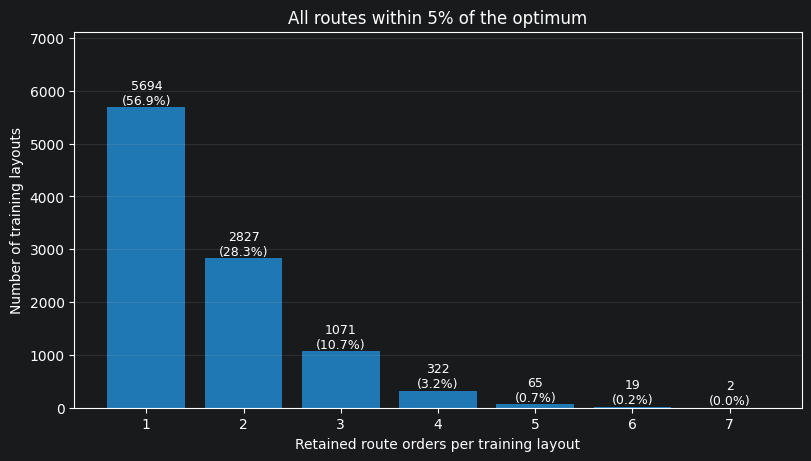

In [4]:
counts = multiroute_train['num_modes']
unique_counts, frequencies = np.unique(counts, return_counts=True)
count_summary = pd.DataFrame({
    'routes_per_layout': unique_counts,
    'num_layouts': frequencies,
    'layout_percent': 100 * frequencies / N_LAYOUTS,
    'num_routes_total': unique_counts * frequencies,
})
per_layout = pd.DataFrame({
    'training_layout_index': np.arange(N_LAYOUTS),
    'num_routes': counts,
    'exact_min_length': multiroute_train['exact_min_lengths'],
    'second_route_gap_percent': 100 * multiroute_train['second_relative_gap'],
    'mode_start_index': multiroute_train['mode_offsets'][:-1],
    'mode_end_index_exclusive': multiroute_train['mode_offsets'][1:],
})
summary = {
    'num_layouts': N_LAYOUTS,
    'total_retained_routes': int(counts.sum()),
    'layouts_with_one_route': int((counts == 1).sum()),
    'layouts_with_multiple_routes': int((counts > 1).sum()),
    'multiple_route_layout_percent': float(100 * (counts > 1).mean()),
    'mean_routes_per_layout': float(counts.mean()),
    'max_routes_per_layout': int(counts.max()),
    'maximum_retained_relative_gap': float(multiroute_train['mode_relative_gaps'].max()),
}
display(count_summary.round(4))
print(json.dumps(summary, indent=2))

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.bar(unique_counts, frequencies, color='tab:blue')
for k, n in zip(unique_counts, frequencies):
    ax.text(k, n, f'{n}\n({100*n/N_LAYOUTS:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_xticks(unique_counts)
ax.set(xlabel='Retained route orders per training layout', ylabel='Number of training layouts',
       title=f'All routes within {100*RELATIVE_SLACK:g}% of the optimum')
ax.set_ylim(0, frequencies.max()*1.25)
ax.grid(axis='y', alpha=.2)
count_figure = fig
plt.show()


## 4. Layout-balanced training sampler

Sample a layout uniformly, then sample one of its retained routes uniformly. Route identity is only used to
construct the supervision target; it is **not** appended to the 13-dimensional network input.

`sampling='single'` uses the original expert and the original sampling order, allowing the baseline to be reproduced.
`sampling='multi'` uses the retained near-optimal route set. Both return float32 `(inputs, velocity_targets)`.

No route selection is performed during inference. The model will still be run from the exact fixed start in the first controlled comparison.


In [5]:
def sample_training_batch(split, batch_size, rng, config, sampling='multi', return_info=False):
    if sampling not in ('single', 'multi'):
        raise ValueError("sampling must be 'single' or 'multi'")
    if batch_size <= 0:
        raise ValueError('batch_size must be positive')
    sigma_0 = float(config['sigma_0'])
    gain = float(config['stabilizing_gain'])
    if not np.isfinite([sigma_0, gain]).all() or sigma_0 <= 0 or gain < 0:
        raise ValueError('Require finite sigma_0 > 0 and stabilizing_gain >= 0')
    n = len(split['targets'])
    layout_indices = rng.integers(0, n, size=batch_size)
    if sampling == 'multi':
        # Each draw has its own upper bound, so every route within the chosen layout is equiprobable.
        mode_local_indices = rng.integers(0, split['num_modes'][layout_indices], size=batch_size)
        route_indices = split['mode_offsets'][layout_indices] + mode_local_indices
        routes = split['mode_routes'][route_indices]
        knots = split['mode_knot_tau'][route_indices]
    else:
        route_indices = np.full(batch_size, -1, dtype=np.int64)
        routes = split['routes'][layout_indices]
        knots = split['knot_tau'][layout_indices]
    tau = rng.uniform(0.0, 1.0, size=batch_size)
    segments = np.clip((tau[:, None] >= knots[:, 1:]).sum(axis=1), 0, 3)
    row = np.arange(batch_size)
    p0 = routes[row, segments]
    p1 = routes[row, segments + 1]
    t0 = knots[row, segments]
    duration = knots[row, segments + 1] - t0
    if np.any(duration <= 0):
        raise ValueError('Expert route contains a non-positive-duration segment')
    positions = p0 + ((tau - t0) / duration)[:, None] * (p1 - p0)
    derivatives = (p1 - p0) / duration[:, None]
    offsets = (sigma_0 * np.exp(-gain * tau))[:, None] * rng.standard_normal((batch_size, 2))
    actions = positions + offsets
    velocity_targets = derivatives - gain * offsets
    inputs = np.concatenate([actions, tau[:, None], split['conditions'][layout_indices]], axis=1)
    inputs = inputs.astype(np.float32)
    velocity_targets = velocity_targets.astype(np.float32)
    if return_info:
        return inputs, velocity_targets, {
            'layout_indices': layout_indices, 'route_indices': route_indices,
            'tau': tau, 'expert_positions': positions, 'expert_derivatives': derivatives,
            'offsets': offsets,
        }
    return inputs, velocity_targets

# A direct replacement for the old training function, using this explicit local config.
# In the future training notebook, pass its CONFIG with the same sigma_0 / stabilizing_gain values.
def sample_batch_multiroute(split, batch_size, rng, config):
    return sample_training_batch(split, batch_size, rng, config, sampling='multi')

inputs, velocity_targets, sample_info = sample_training_batch(
    multiroute_train, 2048, np.random.default_rng(1004), SAMPLE_CONFIG, return_info=True)
assert inputs.shape == (2048, 13) and velocity_targets.shape == (2048, 2)
assert np.isfinite(inputs).all() and np.isfinite(velocity_targets).all()
np.testing.assert_allclose(inputs[:, 3:], source['conditions'][sample_info['layout_indices']], rtol=1e-6, atol=1e-7)
np.testing.assert_allclose(velocity_targets, sample_info['expert_derivatives'] -
                           SAMPLE_CONFIG['stabilizing_gain'] * sample_info['offsets'], rtol=1e-6, atol=1e-7)
print('Example batch:', inputs.shape, velocity_targets.shape)
print('Input: noisy position (2), tau (1), start + four targets (10).')
print('No expert-route label is supplied to the network.')


Example batch: (2048, 13) (2048, 2)
Input: noisy position (2), tau (1), start + four targets (10).
No expert-route label is supplied to the network.


## 5. Compare retained route shapes
按路线数分层、确定性选择布局；最多展示 6 个布局，每个布局最多绘制 6 条路线。绘图上限不影响保存或训练。


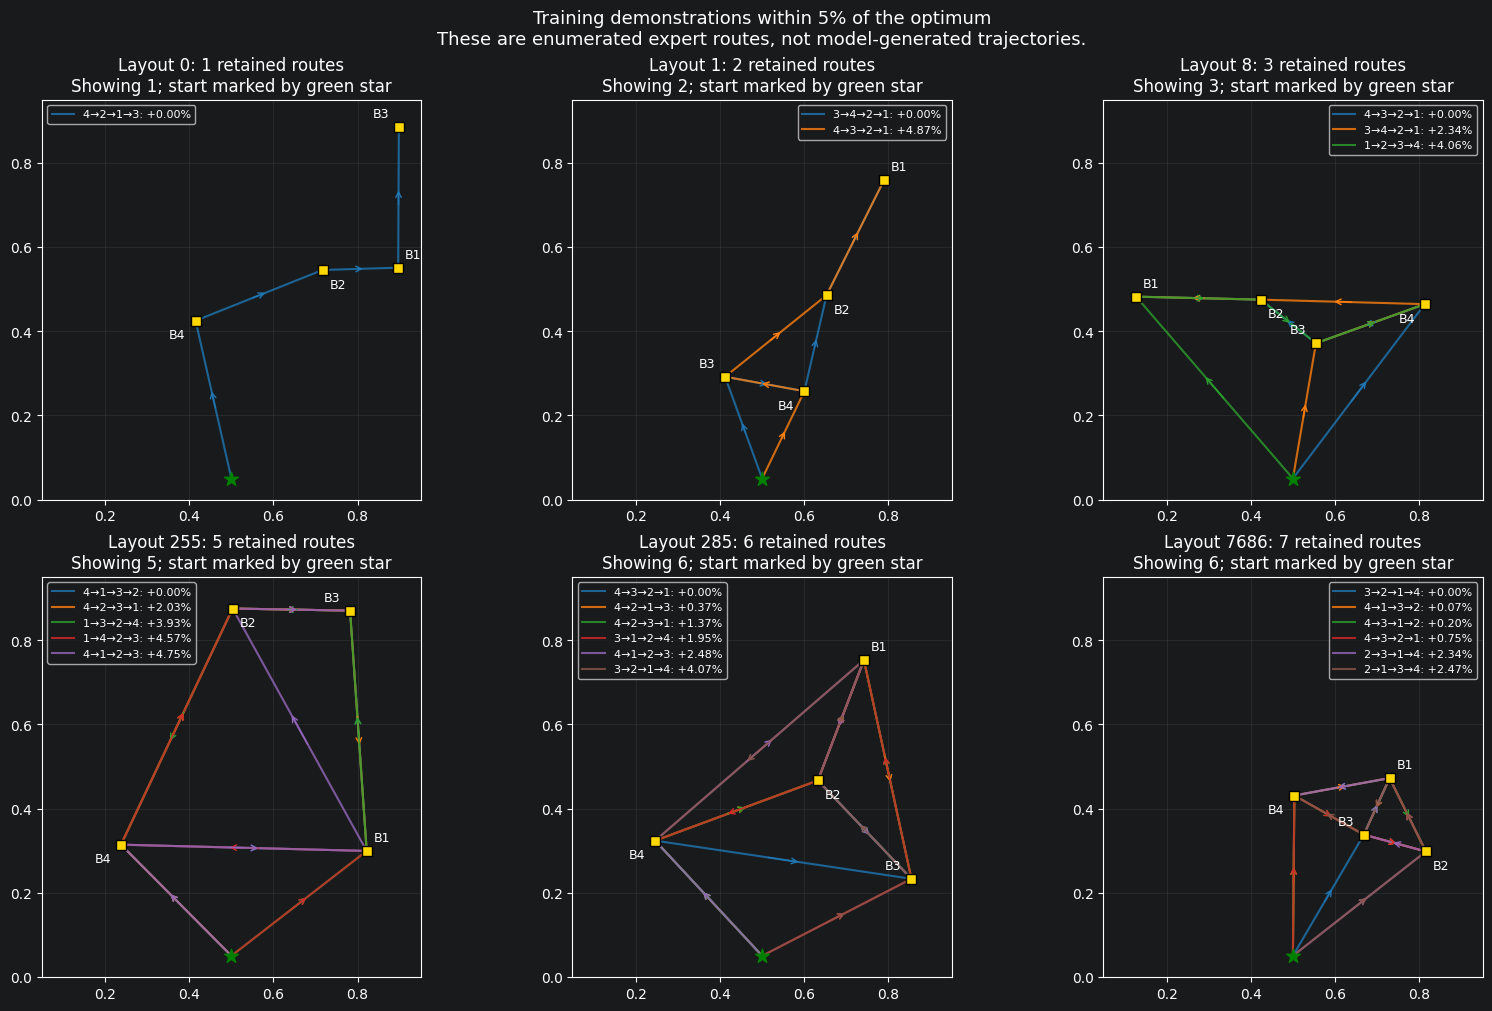

In [6]:
# Choose representative route counts, then one layout per count, filling remaining slots if needed.
count_levels = unique_counts[np.unique(np.linspace(0, len(unique_counts)-1,
                                      min(NUM_EXAMPLE_LAYOUTS, len(unique_counts))).round().astype(int))]
example_indices = [int(np.flatnonzero(counts == k)[0]) for k in count_levels]
if len(example_indices) < min(NUM_EXAMPLE_LAYOUTS, N_LAYOUTS):
    for idx in np.argsort(counts, kind='stable')[::-1]:
        if int(idx) not in example_indices:
            example_indices.append(int(idx))
        if len(example_indices) >= min(NUM_EXAMPLE_LAYOUTS, N_LAYOUTS):
            break

ncols = min(3, len(example_indices))
nrows = int(np.ceil(len(example_indices) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.3*ncols, 5.0*nrows),
                         squeeze=False, constrained_layout=True)
all_coords = np.concatenate([targets64.reshape(-1, 2), starts64], axis=0)
low, high = all_coords.min(axis=0), all_coords.max(axis=0)
margin = max(float((high-low).max()) * .06, .01)
example_rows = []
for ax, idx in zip(axes.flat, example_indices):
    lo, hi = multiroute_train['mode_offsets'][idx:idx+2]
    shown = np.arange(lo, min(hi, lo + MAX_ROUTES_PER_PLOT))
    colors = plt.cm.tab10(np.arange(len(shown)) % 10)
    for color, route_idx in zip(colors, shown):
        route = multiroute_train['mode_routes'][route_idx]
        order = multiroute_train['mode_orders'][route_idx] + 1
        order_str = '→'.join(str(int(x)) for x in order)
        gap = 100 * multiroute_train['mode_relative_gaps'][route_idx]
        ax.plot(route[:, 0], route[:, 1], color=color, alpha=.8, lw=1.5,
                label=f'{order_str}: +{gap:.2f}%')
        # Mark direction at the midpoint of each segment.
        for a, b in zip(route[:-1], route[1:]):
            c, d = a + .43*(b-a), a + .57*(b-a)
            ax.annotate('', xy=d, xytext=c, arrowprops={'arrowstyle':'->', 'color':color, 'lw':1})
        example_rows.append({'training_layout_index':idx, 'mode_index':int(route_idx),
                             'order':order_str, 'relative_gap_percent':gap})
    ax.scatter(targets64[idx, :, 0], targets64[idx, :, 1], marker='s', c='gold',
                edgecolors='black', s=60, zorder=5)
    ax.scatter(*starts64[idx], marker='*', c='green', s=110, zorder=6)
    label_offsets = [(5, 7), (5, -13), (-19, 7), (-19, -13)]
    for j, target in enumerate(targets64[idx], 1):
        ax.annotate(f'B{j}', target, xytext=label_offsets[j-1], textcoords='offset points', fontsize=9)
    ax.set(xlim=(low[0]-margin, high[0]+margin), ylim=(low[1]-margin, high[1]+margin),
           title=f'Layout {idx}: {hi-lo} retained routes\nShowing {len(shown)}; start marked by green star')
    ax.set_aspect('equal')
    ax.grid(alpha=.15)
    ax.legend(fontsize=8, loc='best')
for ax in list(axes.flat)[len(example_indices):]:
    ax.set_visible(False)
fig.suptitle(f'Training demonstrations within {100*RELATIVE_SLACK:g}% of the optimum\n'
             'These are enumerated expert routes, not model-generated trajectories.', fontsize=13)
examples_figure = fig
plt.show()
example_table = pd.DataFrame(example_rows)


## 6. Save a separate dataset version and reusable sampler
首次运行先写入临时目录，校验后再整体安装。再次运行同样设置会复用已有版本；若来源或设置不同，则停止而不覆盖。


In [7]:
# The notebook stores the exact reusable function source explicitly for portability.
SAMPLER_SOURCE = '"""Layout-balanced SFP samples from a prepared multi-route training split."""\nimport numpy as np\n\ndef sample_training_batch(split, batch_size, rng, config, sampling=\'multi\', return_info=False):\n    if sampling not in (\'single\', \'multi\'):\n        raise ValueError("sampling must be \'single\' or \'multi\'")\n    if batch_size <= 0:\n        raise ValueError(\'batch_size must be positive\')\n    sigma_0 = float(config[\'sigma_0\'])\n    gain = float(config[\'stabilizing_gain\'])\n    if not np.isfinite([sigma_0, gain]).all() or sigma_0 <= 0 or gain < 0:\n        raise ValueError(\'Require finite sigma_0 > 0 and stabilizing_gain >= 0\')\n    n = len(split[\'targets\'])\n    layout_indices = rng.integers(0, n, size=batch_size)\n    if sampling == \'multi\':\n        # Each draw has its own upper bound, so every route within the chosen layout is equiprobable.\n        mode_local_indices = rng.integers(0, split[\'num_modes\'][layout_indices], size=batch_size)\n        route_indices = split[\'mode_offsets\'][layout_indices] + mode_local_indices\n        routes = split[\'mode_routes\'][route_indices]\n        knots = split[\'mode_knot_tau\'][route_indices]\n    else:\n        route_indices = np.full(batch_size, -1, dtype=np.int64)\n        routes = split[\'routes\'][layout_indices]\n        knots = split[\'knot_tau\'][layout_indices]\n    tau = rng.uniform(0.0, 1.0, size=batch_size)\n    segments = np.clip((tau[:, None] >= knots[:, 1:]).sum(axis=1), 0, 3)\n    row = np.arange(batch_size)\n    p0 = routes[row, segments]\n    p1 = routes[row, segments + 1]\n    t0 = knots[row, segments]\n    duration = knots[row, segments + 1] - t0\n    if np.any(duration <= 0):\n        raise ValueError(\'Expert route contains a non-positive-duration segment\')\n    positions = p0 + ((tau - t0) / duration)[:, None] * (p1 - p0)\n    derivatives = (p1 - p0) / duration[:, None]\n    offsets = (sigma_0 * np.exp(-gain * tau))[:, None] * rng.standard_normal((batch_size, 2))\n    actions = positions + offsets\n    velocity_targets = derivatives - gain * offsets\n    inputs = np.concatenate([actions, tau[:, None], split[\'conditions\'][layout_indices]], axis=1)\n    inputs = inputs.astype(np.float32)\n    velocity_targets = velocity_targets.astype(np.float32)\n    if return_info:\n        return inputs, velocity_targets, {\n            \'layout_indices\': layout_indices, \'route_indices\': route_indices,\n            \'tau\': tau, \'expert_positions\': positions, \'expert_derivatives\': derivatives,\n            \'offsets\': offsets,\n        }\n    return inputs, velocity_targets\n\n'

build_config = {
    'builder_version': BUILDER_VERSION,
    'source_train_relative_path': SOURCE_PATH.relative_to(PROJECT_ROOT).as_posix(),
    'source_train_sha256': SOURCE_SHA256,
    'relative_slack': RELATIVE_SLACK,
    'boundary_atol': BOUNDARY_ATOL,
    'num_layouts': N_LAYOUTS,
    'total_retained_routes': int(counts.sum()),
    'task': 'fixed-start open path through four targets, no return',
    'enumeration': 'all 24 permutations; target IDs unchanged',
    'parameterization': 'each route has its own normalized cumulative arc length',
    'sampling': 'uniform layout, then uniform retained route within layout',
    'original_fields': sorted(source.keys()),
    'new_fields': sorted(set(multiroute_train) - set(source)),
    'sampler_sha256': hashlib.sha256(SAMPLER_SOURCE.encode('utf-8')).hexdigest(),
    'numpy_version': np.__version__,
}

if sha256_file(SOURCE_PATH) != SOURCE_SHA256:
    raise RuntimeError('Source training file changed while building. Restart from the first cell.')

OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)
if OUTPUT_DIR.exists():
    config_path = OUTPUT_DIR / 'config.json'
    if not config_path.is_file():
        raise FileExistsError('Output directory already exists without a complete config. Choose a new version path.')
    existing_config = json.loads(config_path.read_text(encoding='utf-8'))
    identity = {k:v for k,v in existing_config.items() if k != 'artifact_sha256'}
    if identity != build_config:
        raise FileExistsError('Existing version uses different inputs/settings. Choose a new OUTPUT_DIR.')
    for filename, digest in existing_config['artifact_sha256'].items():
        if sha256_file(OUTPUT_DIR / filename) != digest:
            raise ValueError(f'Existing artifact changed: {filename}. Use a new version directory.')
    print('Reusing the matching, verified existing dataset version.')
else:
    stage = Path(tempfile.mkdtemp(prefix='.multiroute-build-', dir=OUTPUT_DIR.parent))
    try:
        np.savez_compressed(stage / 'train.npz', **multiroute_train)
        # Ensure the persisted archive contains the exact intended arrays.
        with np.load(stage / 'train.npz', allow_pickle=False) as archive:
            if set(archive.files) != set(multiroute_train):
                raise ValueError('Saved array names differ.')
            for key, array in multiroute_train.items():
                np.testing.assert_array_equal(archive[key], array)
        count_summary.to_csv(stage / 'route_count_summary.csv', index=False)
        per_layout.to_csv(stage / 'per_layout_route_counts.csv', index=False)
        example_table.to_csv(stage / 'illustrated_routes.csv', index=False)
        (stage / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
        (stage / 'multiroute_sampler.py').write_text(SAMPLER_SOURCE, encoding='utf-8')
        count_figure.savefig(stage / 'route_count_distribution.png', dpi=180)
        examples_figure.savefig(stage / 'nearoptimal_route_examples.png', dpi=170)
        readme = """# Near-optimal multi-route training split

This version contains training data only. Validation/test layouts were not read or changed.
Existing single-route fields retain their v1 meaning; new candidates are in mode_* arrays.
For layout i, flat candidate rows are mode_offsets[i]:mode_offsets[i+1].
mode_orders are zero-based indices into targets[i]; they are labels, not network inputs.
num_modes is the number of eligible visit orders, not necessarily the number of geometrically distinct paths.
Use multiroute_sampler.sample_training_batch(..., sampling='multi') to sample layout-balanced batches.
Use sampling='single' to reproduce the original expert sampling.
Do not uniformly sample rows of mode_routes: that would overweight layouts with more routes.
There are no model weights or measured success rates in this dataset version.
Do not change optimizer update count or model-selection rule merely because route count increased.
"""
        (stage / 'README.md').write_text(readme, encoding='utf-8')
        artifacts = {p.name:sha256_file(p) for p in stage.iterdir() if p.is_file()}
        saved_config = {**build_config, 'artifact_sha256': artifacts}
        (stage / 'config.json').write_text(json.dumps(saved_config, indent=2), encoding='utf-8')
        if OUTPUT_DIR.exists():
            raise FileExistsError('Another process created the output directory. Nothing was overwritten.')
        stage.rename(OUTPUT_DIR)
        print('Saved new dataset version.')
    finally:
        if stage.exists():
            shutil.rmtree(stage)

print('Directory:', OUTPUT_DIR)
print('Layouts:', N_LAYOUTS, '| retained routes:', int(counts.sum()))
print('Source v1/train.npz unchanged:', sha256_file(SOURCE_PATH) == SOURCE_SHA256)
print('Review route_count_summary.csv, route_count_distribution.png, and nearoptimal_route_examples.png.')


Saved new dataset version.
Directory: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/datasets/v2_nearopt_05pct
Layouts: 10000 | retained routes: 16302
Source v1/train.npz unchanged: True
Review route_count_summary.csv, route_count_distribution.png, and nearoptimal_route_examples.png.


## 7. Integration example for the later controlled training experiment

下面的代码只重新读取新训练数据、导入采样器并生成一个样例 batch，**不会启动训练**。
本 notebook 已完成数据准备；下一阶段还需要将该采样器接入单路线／多路线对照训练循环。
保持原网络、归一化、优化器更新次数和固定起点执行方式，主比较使用同预算结束时的检查点。
验证集仍来自 `datasets/v1/validation.npz`，不能把这些新训练路线混入验证数据。


In [8]:
import importlib.util

with np.load(OUTPUT_DIR / 'train.npz', allow_pickle=False) as archive:
    prepared_train = {key: archive[key].copy() for key in archive.files}

spec = importlib.util.spec_from_file_location('four_target_multiroute_sampler', OUTPUT_DIR / 'multiroute_sampler.py')
sampler_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sampler_module)

# In a later training loop, keep TRAINING_MODE fixed for the whole run.
TRAINING_MODE = 'multi'  # Use 'single' for the corresponding baseline run.
CONFIG = dict(SAMPLE_CONFIG)

def sample_batch(split, batch_size, rng):
    return sampler_module.sample_training_batch(
        split, batch_size, rng, CONFIG, sampling=TRAINING_MODE)

x, y = sample_batch(prepared_train, 2048, np.random.default_rng(1004))
print('Ready for the later training loop:', x.shape, y.shape)
print('No model training has been started.')


Ready for the later training loop: (2048, 13) (2048, 2)
No model training has been started.
